In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
np.random.seed(1001)

In [2]:
# In this notebook I want to showcase the use of Eigenvalues and Eigenvectors for
# non-linear optimization problems. In this particular example we use them to find
# a optimal rotation and translation in 2D.
 
# An often required example in 3D is to find a transfromation in a way, such that some
# points align to a plane as good as possible. Classically this would be done by estimating
# the planes parameters along with the transfromation parameters. Then for each point one
# would go ahead and compute the point to plane residuals, while using those to find the 
# optimal parameters with least squares. 

# However the more planes one has to fit the points on, the more parameters one gets. 
# A plane can be decribed through a vector and a distance from the coordinate systems 
# origin, which mean that for each plane one has to estimate additional 4 parameters. 
# This can go out of hands pretty quickly for many planes.

# Now by using the eigenvalues and eigenvectors one can get rid of this issue, while still
# precisely finding the optimal solution to the given problem. What is here described with
# a plane and points in 3D, will now for simplicity be demonstarted with a line and points
# in 2D. As long as one wants to flatten data points to a hyperplane the optimization 
# through eigenvalues and eigenvectors offers a very elegant method to do so in any 
# dimension.

In [3]:
# First we define a function that outputs for an input vector v of shape (3) a rotation
# and translation with shapes (2, 2) and (2, 1). The first two values of v thereby 
# correspond to the x and y translation values, the last entry of v to the rotation angle. 
# If derivative is set to True, the jacobians of the rotation and translation with 
# respect to v are output as well (where the first axis corresponds to v, so the outputs 
# are of shape (3, 2, 2) and (3, 2, 1)).

def transformation(v, derivative=False):
    x, y, a = v
    
    R = np.array([[np.cos(a), -np.sin(a)],
                  [np.sin(a),  np.cos(a)]])
    p = np.array([[x],
                  [y]])
    
    if derivative:
        d_R = np.array([[[0, 0],
                         [0, 0]],
                        [[0, 0],
                         [0, 0]],
                        [[-np.sin(a), -np.cos(a)],
                         [ np.cos(a), -np.sin(a)]]]).reshape(3, 1, 1, 1, 2, 2)
        d_p = np.array([[[1],
                         [0]],
                        [[0],
                         [1]],
                        [[0],
                         [0]]]).reshape(3, 1, 1, 1, 2, 1)
        
        return R, p, d_R, d_p
    
    else:
        return R, p

In [4]:
# Now lets create some sample data. In particular we here want to create some lines.

n_lines = 3
n_points_per_line = 25

# create some almost linear points alomng the x-axis.
points = np.random.randn(1, 1, n_points_per_line, 2, 1) * np.array([3e-1, 1e-2]).reshape(2, 1)

# create some variations of this line by rotating and translating it.
for i in range(n_lines - 1):
    v = np.random.randn(3)
    R, p = transformation(v)
    
    points = np.append(points, R @ points[[0], ...] + p, axis=0)

# The shape will be of the form (n_lines, 1, n_points_per_line, 2, 1), so we have n_lines
# of n_points_per_line points with two x and y coordinates each (seen as (2, 1)).
# The reason for the 1 at the first axis will become obvious soon.
points.shape

(3, 1, 25, 2, 1)

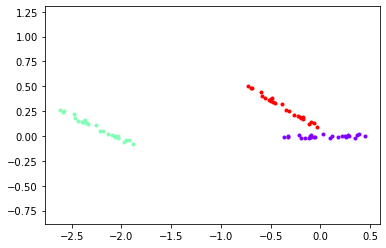

In [5]:
# Lets have a look at the data.

colors = plt.cm.rainbow(np.linspace(0, 1, n_lines))
for i in range(n_lines):
    plt.scatter(points[i, :, :, 0, 0], points[i,:, :, 1, 0], 
                color=colors[i, :], marker='.')
    
plt.axis('equal')
plt.show()

In [6]:
# We now assume this data is altered by a rotation and translation, specified by v below.

v = np.array([0.5, 1, 2]) # x-translation, y-translation, rotations angle

R, p = transformation(v)
points = np.concatenate([points, R @ points + p], axis=1)

# Lets also add some noise to those transformed points
noise_level = 1e-2
points[:, 1, :, :, :] += np.random.randn(n_lines, n_points_per_line, 2, 1) * noise_level

# We now see the use of thefirst axis, all our points are neatly vectorized. The unaltered
# and altered points are specified at exactly this axis
points.shape

(3, 2, 25, 2, 1)

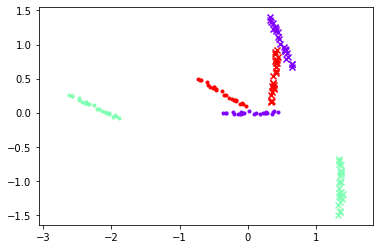

In [7]:
# Let us take a second look at the data, the altered points are shown by the x-marker.
# We can see how the two line sets, marked by dots and crosses, differ by a rotation and
# translation

colors = plt.cm.rainbow(np.linspace(0, 1, n_lines))
markers = ['.', 'x']
for i in range(n_lines):
    for j in range(2):
        plt.scatter(points[i, j, :, 0, 0], points[i, j, :, 1, 0], 
                    color=colors[i, :], marker=markers[j])
    
plt.axis('equal')
plt.show()

In [8]:
# We further define a function computing for each pair of lines (the original and 
# transformed one) its smallest eigenvalue and corresponding eigenvector. That is, for each
# such line we do a Principal Component Analysis by computing the covariance matrix of the
# underlying points. A finer explanation will be given in the next cell.

def eigen(v, derivative=False):
    if derivative:
        R, p, d_R, d_p = transformation(v, derivative=True)
        R = np.stack([R, np.eye(2)]).reshape(1, 2, 1, 2, 2)
        p = np.stack([p, np.zeros((2, 1))]).reshape(1, 2, 1, 2, 1)
        d_R = np.concatenate([d_R, np.zeros((3, 1, 1, 1, 2, 2))], axis=2)
        d_p = np.concatenate([d_p, np.zeros((3, 1, 1, 1, 2, 1))], axis=2)

        points_ = (R @ points + p).reshape(n_lines, -1, 2, 1)
        d_points_ = (d_R @ points + d_p).reshape(3, n_lines, -1, 2, 1)
        
        mu = np.mean(points_, axis=-3)
        d_mu = np.mean(d_points_, axis=-3)
        S = np.mean(points_ @ np.swapaxes(points_, -1, -2), axis=-3) - \
            mu @ np.swapaxes(mu, -1, -2)
        d_S = np.mean(d_points_ @ np.swapaxes(points_, -1, -2), axis=-3) + \
              np.mean(points_ @ np.swapaxes(d_points_, -1, -2), axis=-3) - \
              d_mu @ np.swapaxes(mu, -1, -2) - \
              mu @ np.swapaxes(d_mu, -1, -2)

        w, v = np.linalg.eigh(S)
        w, v = w[:, [0], None], v[:, :, [0]]

        d_w = (np.swapaxes(v, -1, -2) @ d_S @ v)
        d_v = np.linalg.pinv(w * np.eye(2) - S) @ d_S @ v
        
        return w, v, d_w, d_v
    
    else:
        R, p = transformation(v, derivative=False)
        R = np.stack([R, np.eye(2)]).reshape(1, 2, 1, 2, 2)
        p = np.stack([p, np.zeros((2, 1))]).reshape(1, 2, 1, 2, 1)
        
        points_ = (R @ points + p).reshape(n_lines, -1, 2, 1)
        
        mu = np.mean(points_, axis=-3)
        S = np.mean(points_ @ np.swapaxes(points_, -1, -2), axis=-3) - \
            mu @ np.swapaxes(mu, -1, -2)

        w, v = np.linalg.eigh(S)
        w, v = w[:, [0], None], v[:, :, [0]]

        return w, v

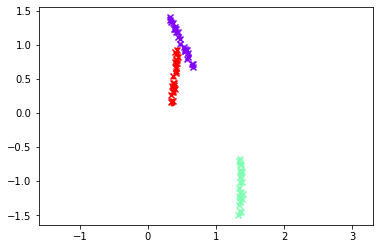

In [9]:
# The ultimate task of this notebook is to estimate the previously specified transfomration
# parameters (the v array from before) soley by looking at the data. That is how can we
# move the dotted points in the image above, such that they align well with the crossed
# ones.

# The optimal solution therefore looks like this. The two point sets overlap each other well.
R, p = transformation(v)
points_ = points.copy()
points_[:, 0, :, :, :] = R @ points_[:, 0, :, :, :] + p

colors = plt.cm.rainbow(np.linspace(0, 1, n_lines))
markers = ['.', 'x']
for i in range(n_lines):
    for j in range(2):
        plt.scatter(points_[i, j, :, 0, 0], points_[i, j, :, 1, 0], 
                    color=colors[i, :], marker=markers[j])
    
plt.axis('equal')
plt.show()

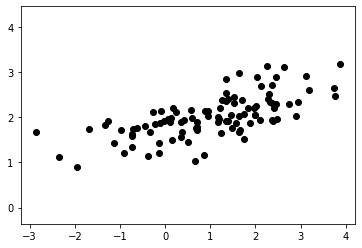

In [10]:
# We want to achive this task, finding v, by looking at eigenvalues and eigenvectors. 
# So what do we mean here? Lets look at the following 2D datapoints below. We create
# some points specified by a gaussian distribution. First lets define the covariance
# and the mean:
cov = np.array([[2.0, 0.4], [0.4, 0.2]])
mean = np.array([1, 2])

data = np.random.multivariate_normal(mean, cov, size=(100))

# Let us look at it
plt.scatter(data[:, 0], data[:, 1], c='k')
plt.axis('equal')
plt.show()

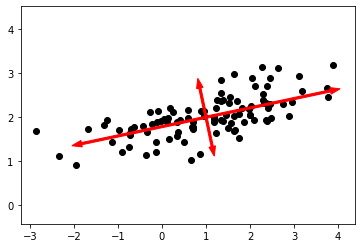

array([0.11511422, 2.08488578])

In [11]:
# We can see this data has a linear shape. This can also be observed through the covariance
# matrix of it. If we compute the eigenvalues of eigenvectors and plot them on the data
# we can observe how their direction and spread dictates the form of our data
eigenvalues, eigenvectors = np.linalg.eigh(cov)

plt.scatter(data[:, 0], data[:, 1], c='k')
plt.arrow(mean[0], mean[1], 
          eigenvectors[0, 0] * 2 * np.sqrt(eigenvalues[0]), 
          eigenvectors[1, 0] * 2 * np.sqrt(eigenvalues[0]),
         color='r', width=0.05)
plt.arrow(mean[0], mean[1], 
          -eigenvectors[0, 0] * 2 * np.sqrt(eigenvalues[0]), 
          -eigenvectors[1, 0] * 2 * np.sqrt(eigenvalues[0]),
         color='r', width=0.05)
plt.arrow(mean[0], mean[1], 
          eigenvectors[0, 1] * 2 * np.sqrt(eigenvalues[1]), 
          eigenvectors[1, 1] * 2 * np.sqrt(eigenvalues[1]),
         color='r', width=0.05)
plt.arrow(mean[0], mean[1], 
          -eigenvectors[0, 1] * 2 * np.sqrt(eigenvalues[1]), 
          -eigenvectors[1, 1] * 2 * np.sqrt(eigenvalues[1]),
         color='r', width=0.05)
plt.axis('equal')
plt.show()

# That is the eigenvectors gives us the directions along which the data is spread out,
# while the magnitute is given by the corresponding eigenvalue. Now if we want to oberve
# how planar some datapoints are, we can therefore look at the eigenvalues. The smaller
# the smallest of the two eigenvalues is (while the other one is big), the more linear
# our points are. In our example the two eigenvalues are:
eigenvalues

In [12]:
# Now in praxis we do not know the covariance matrix, as we are only given the data points.
# However from them we can compute it ourself from the data. This is exactly what we defined
# our eigen function for. It computes for our line tuples the covariance matrix and from
# there the eigenvalues and eigenvectors (potentially together with the jacobians respective
# the transfomration parameters v).

np.cov(data, rowvar=False)

array([[1.85976963, 0.43551817],
       [0.43551817, 0.22087087]])

In [13]:
# With this theory in mind, lets look at the eigenvalues of our previous sample lines above.
# If the two point sets are well aligned, that is we know the optimal transformation v,
# all of our lines have a very small smallest eigenvalue. This makes sense since they 
# are almost linear, as can be seen in the image above

eigenvalues, eigenvectors = eigen(v)
eigenvalues.reshape(-1)

array([0.00015357, 0.00018076, 0.00015909])

In [14]:
# If instead we take the unaligned lines, that is we compute the the eigenvalues of our
# line tuples while they are far apart, we can see how their smallest eigenvalues are in
# fact bigger. This makes sense, as in here the line tuples aren't actually lines at all,
# but randomly scattered points in space.

eigenvalues, eigenvectors = eigen(np.array([0, 0, 0]))
eigenvalues.reshape(-1)

array([0.0398517 , 0.02715278, 0.03966742])

In [15]:
# So if we want to find the optimal values for v we can look at the eigenvalues of the
# line point tuples. If we manage to gradually decraese them we will be able to find the
# desired values. This sounds like an optimization problem!

# And indeed, if we take each of the lines eigenvalues as a residual we can find the 
# solutation through classical least squares optimization. Now in theory the eigenvalues
# aren't fully differentiable. In fact we get singularities for the cases where the smallest
# eigenvalue for a point set cannot uniquely be determined. However this means that if
# we start close enough to the actual solution, and our eigenvalues stay unique throughout
# the whole process, we are well off.

In [16]:
# So lets try it out! We define our loss functions, the derivative function and our initial
# guess. We observe that we can find the optimal solution very precisely (remember that we
# also added in noise before). However we see that we needed a lot of iterations to find it.
# We proved that eigenvalues can in fact be used for finding optimal transformations. Now
# we only need to make it work quicker.

def f(x):
    w, v = eigen(x, derivative=False)
    return w.reshape(-1)
    
def jac_f(x):
    w, v, d_w, d_v = eigen(x, derivative=True)
    return d_w.reshape(3, -1).T

x_0 = np.array([0, 0, 0])
res = least_squares(f, x_0, jac_f, verbose=2,
                    # we cap the angle range into [-pi, pi] since it is circular
                    bounds=((-np.inf, -np.inf, -np.pi), (np.inf, np.inf, np.pi)))

print('Optimal solution: ', res.x)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9495e-03                                    5.19e-03    
       1              2         1.3321e-03      6.17e-04       1.23e+00       2.53e-03    
       2              3         1.0228e-03      3.09e-04       1.01e+00       1.60e-03    
       3              4         2.6088e-04      7.62e-04       1.07e+00       1.35e-03    
       4              5         4.0474e-05      2.20e-04       9.18e-01       3.33e-04    
       5              6         2.0306e-05      2.02e-05       2.01e+00       3.29e-04    
       6              7         1.0324e-06      1.93e-05       6.19e-01       1.39e-04    
       7              8         9.9522e-08      9.33e-07       4.16e-02       1.26e-05    
       8             10         9.1312e-08      8.21e-09       9.84e-02       1.01e-05    
       9             11         4.6281e-08      4.50e-08       2.50e-02       6.66e-07    

In [17]:
# Instead of taking the eigenvalues as residuals we can also compute the point to line
# distance, as it would be done classically in theese kind of problems. However as opposed
# to those, with our method we do not need to estimate the lines properties through 
# extra parameters. If you remeber from before, we actually get the description of each
# line through the eigenvector corresponding to the smallest eigenvalue. So instaed we can
# take as residuals the distance of each point to the line computed through the eigendecom-
# position, that is instead of only estimating the transformation parameters we estimate
# the lines properties as well. However without the need of any extra parameters, but
# soley by looking at the covariance matrix of our data points. Trying it out, we indeed
# see a great improvement in speed

def f(x):
    w, v = eigen(x, derivative=False)
    
    R, p = transformation(x, derivative=False)
    R = np.stack([R, np.eye(2)]).reshape(1, 2, 1, 2, 2)
    p = np.stack([p, np.zeros((2, 1))]).reshape(1, 2, 1, 2, 1)
        
    points_ = (R @ points + p).reshape(n_lines, -1, 2, 1)
        
    mu = np.mean(points_, axis=-3, keepdims=True)
    distances = np.swapaxes(v.reshape(-1, 1, 2, 1), -1, -2) @ (points_ - mu)

    return distances.reshape(-1)
    
def jac_f(x):
    w, v, d_w, d_v = eigen(x, derivative=True)
    
    R, p, d_R, d_p = transformation(x, derivative=True)
    R = np.stack([R, np.eye(2)]).reshape(1, 2, 1, 2, 2)
    p = np.stack([p, np.zeros((2, 1))]).reshape(1, 2, 1, 2, 1)
    d_R = np.concatenate([d_R, np.zeros((3, 1, 1, 1, 2, 2))], axis=2)
    d_p = np.concatenate([d_p, np.zeros((3, 1, 1, 1, 2, 1))], axis=2)

    points_ = (R @ points + p).reshape(n_lines, -1, 2, 1)
    d_points_ = (d_R @ points + d_p).reshape(3, n_lines, -1, 2, 1)
        
    mu = np.mean(points_, axis=-3, keepdims=True)
    d_mu = np.mean(d_points_, axis=-3, keepdims=True)
    
    distances = np.swapaxes(d_v.reshape(3, -1, 1, 2, 1), -1, -2) @ (points_ - mu) + \
                np.swapaxes(v.reshape(-1, 1, 2, 1), -1, -2) @ (d_points_ - d_mu)
    
    return distances.reshape(3, -1).T

x_0 = np.array([0, 0, 0])
res = least_squares(f, x_0, jac_f, verbose=2,
                    bounds=((-np.inf, -np.inf, -np.pi), (np.inf, np.inf, np.pi)))

print('Optimal solution: ', res.x)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.6668e+00                                    3.10e+00    
       1              2         1.5695e+00      1.10e+00       1.15e+00       3.44e+00    
       2              3         4.0126e-01      1.17e+00       7.34e-01       1.72e+00    
       3              4         1.7409e-01      2.27e-01       4.13e-01       1.56e+00    
       4              5         3.8270e-02      1.36e-01       7.43e-01       1.34e+00    
       5              6         1.2680e-02      2.56e-02       1.11e-01       5.07e-01    
       6              7         1.2278e-02      4.02e-04       1.76e-02       2.18e-03    
       7              8         1.2278e-02      5.65e-09       3.43e-05       4.30e-08    
       8              9         1.2278e-02      4.34e-17       3.69e-09       1.13e-11    
`gtol` termination condition is satisfied.
Function evaluations 9, initial cost 2.6668e+00